# **Modeling setup: protocol, splits and baseline**

This notebook documents the modeling protocol shared by every model notebook and checks the building blocks in `src/rent_model/` end to end. No model is trained here except a naive baseline used as a smoke test of the pipeline.

## Protocol
1. Two tracks, trained separately: `jeonse` (target `deposit_10k_krw`) and `wolse` (target `monthly_rent_10k_krw`). The annual cash cost of a Wolse contract is 12 x the monthly rent. The deposit is not a feature in the Wolse track.
2. The model target is `y = log1p(target)`; predictions are back-transformed with `expm1`.
3. Strict temporal split by `contract_date`: TRAIN 2022-01-01..2024-12-31, TEST 2025. No random split. Imputation, encoding, scaling, clustering and hyperparameters are fit on TRAIN only.
4. Tuning uses a 3-fold expanding-window time CV inside TRAIN. The final projection refits on 2022-2025.
5. Forbidden features: `lease_type` within a track, the other track's target, the deposit in the Wolse track, `monthly_rent` and every `previous_*` column, `contract_period`/`contract_start`/`contract_end`, `registration_year`, the raw `contract_date`, `legal_dong_code`, the lot-number columns, the zone columns and `row_id`.
6. Allowed features: `district_name`, `building_type`, `contract_type`, `renewal_right_used`, `log_area`, `floor`, `floor_missing`, `building_age`, `month_of_year` (with sin/cos for linear models), `t` (only in "time" variants) and the optional `legal_dong`.
7. Primary metric: WAPE. Also MAE, MdAPE, median bias %, aggregate bias %, MAPE by district x quarter, and RMSE and R2 on the log scale.
8. Model selection: lowest WAPE on TEST with the one-standard-error rule (paired bootstrap); ties go to the simpler and less biased model.
9. Projections for 2026-2028 are extrapolation scenarios, since only 48 months of data are available, and must be labelled as such.
10. Every model notebook ends by saving predictions and metrics under `reports/`, never overwriting another model's files.

The random seed is defined once, in `src/rent_model/config.py`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import build_features, forbidden_columns, select_track
from rent_model.io import save_run
from rent_model.splits import expanding_window_folds, temporal_split

pd.set_option('display.max_columns', None)
print(f"RANDOM_SEED = {config.RANDOM_SEED}")

RANDOM_SEED = 42


## Cleaned data

`load_clean` reproduces the cleaning of `Notebook.ipynb` (section 4) and asserts the expected row counts.

In [2]:
df = load_clean()
print(f"Rows: {len(df):,}")
print(df['lease_type'].value_counts().to_string())

Rows: 387,326
lease_type
Monthly rent             210543
Jeonse (deposit only)    176783


## Temporal split and time-series folds

In [3]:
split_rows = []
for track in config.TRACKS:
    train, test = temporal_split(select_track(df, track))
    split_rows.append({
        'track': track,
        'train_rows': len(train),
        'test_rows': len(test),
        'train_start': train['contract_date'].min().date(),
        'train_end': train['contract_date'].max().date(),
        'test_start': test['contract_date'].min().date(),
        'test_end': test['contract_date'].max().date(),
    })
display(pd.DataFrame(split_rows).set_index('track'))

,train_rows,test_rows,train_start,train_end,test_start,test_end
track,,,,,,
jeonse,138848,37935,2022-01-01,2024-12-31,2025-01-01,2025-12-31
wolse,152714,57829,2022-01-01,2024-12-31,2025-01-01,2025-12-31


In [4]:
fold_rows = []
for track in config.TRACKS:
    train, _ = temporal_split(select_track(df, track))
    for k, (train_pos, valid_pos) in enumerate(expanding_window_folds(train, config.N_CV_SPLITS), start=1):
        fold_rows.append({
            'track': track,
            'fold': k,
            'train_rows': len(train_pos),
            'train_end': train['contract_date'].iloc[train_pos].max().date(),
            'valid_start': train['contract_date'].iloc[valid_pos].min().date(),
            'valid_end': train['contract_date'].iloc[valid_pos].max().date(),
            'valid_rows': len(valid_pos),
        })
display(pd.DataFrame(fold_rows).set_index(['track', 'fold']))

train_rows   train_end valid_start   valid_end  valid_rows
track  fold                                                            
jeonse 1          50327  2022-12-31  2023-01-01  2023-08-31       32062
       2          82389  2023-08-31  2023-09-01  2024-04-30       30026
       3         112415  2024-04-30  2024-05-01  2024-12-31       26433
wolse  1          50860  2022-12-31  2023-01-01  2023-08-31       34709
       2          85569  2023-08-31  2023-09-01  2024-04-30       31839
       3         117408  2024-04-30  2024-05-01  2024-12-31       35306

## Monthly median target and the train/test boundary

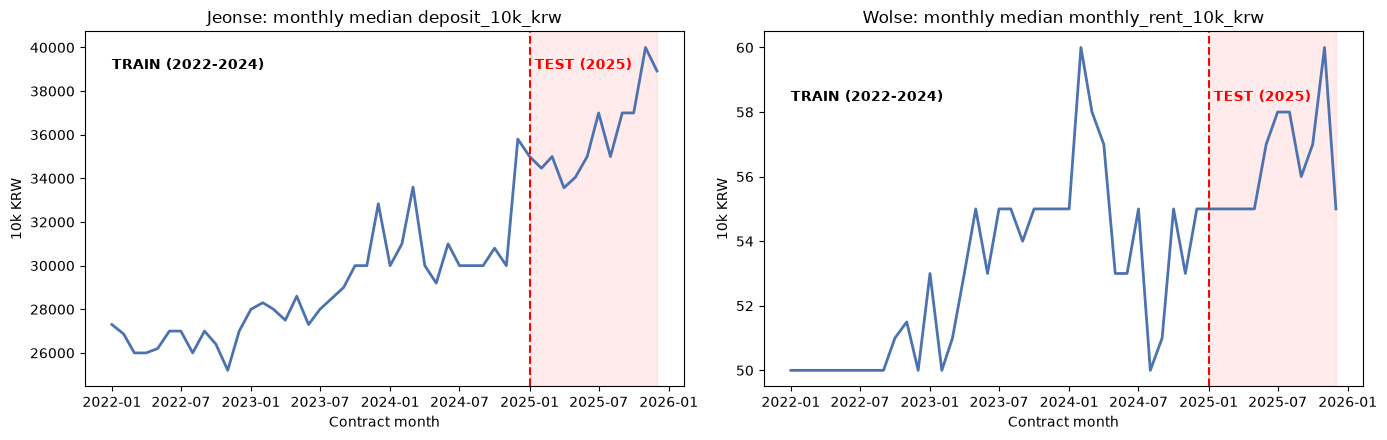

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (track, spec) in zip(axes, config.TRACKS.items()):
    monthly = select_track(df, track).groupby('contract_month')[spec['target']].median()
    ax.plot(monthly.index, monthly.values, color='#4C72B0', linewidth=2)
    ax.axvline(config.TEST_START, color='red', linestyle='--', linewidth=1.5)
    ax.axvspan(config.TEST_START, monthly.index.max(), color='red', alpha=0.08)
    top = ax.get_ylim()[1]
    ax.text(monthly.index.min(), top * 0.97, 'TRAIN (2022-2024)', va='top', fontweight='bold')
    ax.text(config.TEST_START, top * 0.97, ' TEST (2025)', va='top', color='red', fontweight='bold')
    ax.set_title(f"{track.capitalize()}: monthly median {spec['target']}")
    ax.set_xlabel('Contract month')
    ax.set_ylabel('10k KRW')
plt.tight_layout()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / '00_monthly_median_target.png', dpi=150)
plt.show()

## TEST (2025) vs TRAIN median of the target

In [6]:
change_rows = []
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    target = spec['target']
    train_median = train[target].median()
    train_2024_median = train.loc[train['contract_date'].dt.year == 2024, target].median()
    test_median = test[target].median()
    change_rows.append({
        'track': track,
        'train_median': train_median,
        'train_2024_median': train_2024_median,
        'test_2025_median': test_median,
        'change_vs_train_pct': (test_median / train_median - 1) * 100,
        'change_vs_2024_pct': (test_median / train_2024_median - 1) * 100,
    })
display(pd.DataFrame(change_rows).set_index('track').round(2))

,train_median,train_2024_median,test_2025_median,change_vs_train_pct,change_vs_2024_pct
track,,,,,
jeonse,28350.0,30462.5,35500.0,25.22,16.54
wolse,52.0,55.0,55.0,5.77,0.00


## Feature matrices

In [7]:
for track in config.TRACKS:
    base = build_features(df, track)
    full = build_features(df, track, include_time=True, include_legal_dong=True)
    print(f"{track}: {base.shape[1]} base features, {full.shape[1]} with t and legal_dong, "
          f"{len(full):,} rows, forbidden columns present: {forbidden_columns(full.columns, track)}")
print()
display(build_features(df, 'jeonse', include_time=True).head(3))

jeonse: 11 base features, 13 with t and legal_dong, 176,783 rows, forbidden columns present: []
wolse: 11 base features, 13 with t and legal_dong, 210,543 rows, forbidden columns present: []



,district_name,building_type,contract_type,renewal_right_used,log_area,floor,floor_missing,building_age,month_of_year,month_sin,month_cos,t
0,Jongno-gu,Apartment,Renewal,Yes,4.366278,8.0,0,43.0,1,0.5,0.866025,0
4,Seongdong-gu,Row house / Villa (multi-unit),Not specified,No/Not reported,3.642574,1.0,0,30.0,1,0.5,0.866025,0
9,Dongdaemun-gu,Apartment,New,No/Not reported,3.999301,12.0,0,1.0,1,0.5,0.866025,0


## Smoke test: global TRAIN median baseline

The baseline predicts the TRAIN median of the target for every TEST row. It proves the pipeline (cleaning, split, metrics, `save_run`) end to end and gives the reference WAPE that any model must beat.

In [8]:
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    target = spec['target']
    constant = float(train[target].median())
    y_pred = np.full(len(test), constant)
    save_run(track, 'baseline_train_median', test[target].to_numpy(), y_pred,
             meta={'description': 'global TRAIN median of the target', 'constant': constant},
             context=test[['district_name', 'contract_date']])

baseline_rows = []
for track in config.TRACKS:
    runs = json.loads((config.METRICS_DIR / f'{track}__baseline_train_median.json').read_text(encoding='utf-8'))
    baseline_rows.append(runs[-1])
columns = ['track', 'n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct',
           'rmse_log', 'r2_log', 'mape_dq_median_pct']
display(pd.DataFrame(baseline_rows)[columns].set_index('track').round(3))

,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log,mape_dq_median_pct
track,,,,,,,,,
jeonse,37935,55.559,25041.037,49.011,-20.141,-37.099,0.781,-0.068,65.163
wolse,57829,56.553,42.395,40.909,-5.455,-30.634,0.858,-0.000,94.193


## What the outputs show

- **Split.** TEST contains every 2025 contract: 37,935 Jeonse and 57,829 Wolse rows, against 138,848 and 152,714 rows in TRAIN. The three expanding-window folds validate on 2023-01-01..2023-08-31, 2023-09-01..2024-04-30 and 2024-05-01..2024-12-31, always after their training window.
- **Level shift in TEST.** The median Jeonse deposit in 2025 (35,500) is 25.22% above the TRAIN median (28,350) and 16.54% above 2024 (30,462.5). A model fit on TRAIN therefore faces a higher price level in TEST, and designs without a time trend are expected to under-predict. The median Wolse rent moves less: 55 in 2025 against 52 in TRAIN (+5.77%) and 55 in 2024 (0.00%).
- **Baseline.** The constant TRAIN median reaches a WAPE of 55.559% in the Jeonse track and 56.553% in the Wolse track, with an aggregate bias of -37.099% and -30.634% and an R2 on the log scale of -0.068 and about zero (-0.000). These are the reference values that any model must clearly beat.

The baseline predictions are written to `reports/predictions/` (not tracked by git) and its metrics to `reports/metrics/` (tracked), using the same `save_run` function as every later model.
